# 1. Decision Tree vs Random Forest Experiment

## 1. IMPORT LIBRARIES

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 2. LOAD CLASSIFICATION DATASET

In [94]:
df = pd.read_csv("dataset/titanic/train.csv")

X = df.drop("Survived", axis = 1)
y = df["Survived"]

X = df[
    [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare"
    ]
]

y = df["Survived"]

X = X.fillna(X.median())


## 3. TRAIN/TEST SPLIT

In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

## 4. DECISION TREE

In [96]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_train_predictions = decision_tree.predict(X_train)
dt_test_predictions = decision_tree.predict(X_test)

dt_train_accuracy = accuracy_score(
    y_train,
    dt_train_predictions
)

dt_test_accuracy = accuracy_score(
    y_test,
    dt_test_predictions
)


## 5. RANDOM FOREST

In [97]:
random_forest = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42
)

random_forest.fit(X_train, y_train)

rf_train_predictions = random_forest.predict(X_train)
rf_test_predictions = random_forest.predict(X_test)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_predictions
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_predictions
)

## 6. BASIC COMPARISION

In [98]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Train Accuracy": [
        dt_train_accuracy,
        rf_train_accuracy
    ],
    "Test Accuracy": [
        dt_test_accuracy,
        rf_test_accuracy
    ]
})

print("\nDecision Tree vs Random Forest")
print(comparison)


Decision Tree vs Random Forest
           Model  Train Accuracy  Test Accuracy
0  Decision Tree        0.963483       0.553073
1  Random Forest        0.963483       0.597765


## Observation:

Random Forest achieved higher test accuracy than the single Decision Tree, indicating better generalization. Both models had the same training accuracy, but the Decision Tree showed stronger overfitting.

## 7. EXPERIMENT — NUMBER OF TREES

In [99]:
n_estimators_values = [10, 50, 100, 200]

results_estimators = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators = n,
        random_state = 42
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    results_estimators.append({
        "n_estimators": n,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

    

estimators_df = pd.DataFrame(results_estimators)

print("\nRandom Forest — n_estimators Experiment")
print(estimators_df)


Random Forest — n_estimators Experiment
   n_estimators  Train Accuracy  Test Accuracy
0            10        0.945225       0.575419
1            50        0.963483       0.603352
2           100        0.963483       0.597765
3           200        0.963483       0.608939


## Observation:

Increasing the number of trees improved test accuracy overall, although the improvement was not consistent at every step. The 200-tree model achieved the highest test accuracy, showing that more trees can improve stability and generalization.

## 8. EXPERIMENT — MAX DEPTH

In [100]:
max_depth_values = [2, 4, 6, 10, None]

results_depth = []

for depth in max_depth_values:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    results_depth.append({
        "max_depth": depth,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })


depth_df = pd.DataFrame(results_depth)

print("\nRandom Forest — max_depth Experiment")
print(depth_df)


Random Forest — max_depth Experiment
   max_depth  Train Accuracy  Test Accuracy
0        2.0        0.730337       0.675978
1        4.0        0.772472       0.703911
2        6.0        0.800562       0.698324
3       10.0        0.893258       0.608939
4        NaN        0.963483       0.597765


## Observation:

Test accuracy was highest at max_depth = 4. Increasing depth beyond this increased training accuracy but reduced test accuracy, indicating overfitting.

## Important insight

This experiment clearly demonstrates:
More complexity ≠ better model.
Your Random Forest became more accurate on the training data as depth increased, but its generalization became worse after depth 4.

## 9. FINAL COMPARISON

In [101]:
print("\n" + "=" * 60)
print("FINAL COMPARISIOIN")
print("=" * 60)

print("\nDecision Tree:")
print(f"Train Accuracy: {dt_train_accuracy:.4f}")
print(f"Test Accuracy: {dt_test_accuracy:.4f}")

print("\nRandom Forest:")
print(f"Train Accuracy: {rf_train_accuracy:.4f}")
print(f"Test Accuracy: {rf_test_accuracy:.4f}")


FINAL COMPARISIOIN

Decision Tree:
Train Accuracy: 0.9635
Test Accuracy: 0.5531

Random Forest:
Train Accuracy: 0.9635
Test Accuracy: 0.5978


## Observation:

Both models achieved the same training accuracy, but Random Forest achieved higher test accuracy than the Decision Tree. This indicates that the ensemble generalized better on the test data.

## 10. VISUALIZE n_estimators EXPERIMENT

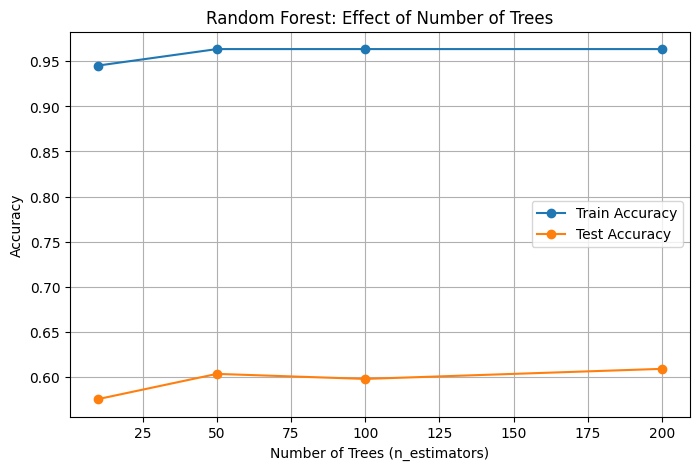

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(
    estimators_df["n_estimators"],
    estimators_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    estimators_df["n_estimators"],
    estimators_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest: Effect of Number of Trees")
plt.legend()
plt.grid(True)

plt.show()

## 11. VISUALIZE max_depth EXPERIMENT

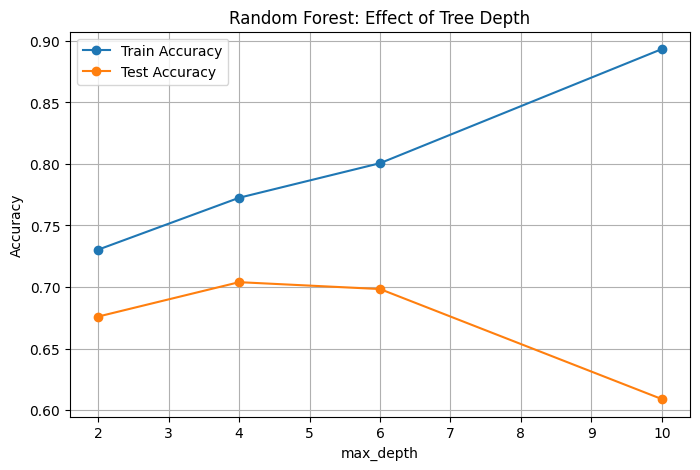

In [103]:
depth_plot_df = depth_df.copy()

# Replace None only for plotting
depth_plot_df["Depth"] = depth_plot_df["max_depth"].apply(
    lambda x: 15 if x is None else x
)

plt.figure(figsize=(8, 5))

plt.plot(
    depth_plot_df["Depth"],
    depth_plot_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    depth_plot_df["Depth"],
    depth_plot_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Random Forest: Effect of Tree Depth")
plt.legend()
plt.grid(True)

plt.show()

## 12. LEARNING QUESTIONS

In [104]:
print("\n" + "=" * 60)
print("DAY 4 LEARNING QUESTIONS")
print("=" * 60)

print("""
1. Which model has higher training accuracy?

2. Which model has higher test accuracy?

3. Does higher training accuracy automatically mean better
   generalization?

4. What happens when n_estimators increases from 10 to 200?

5. Does adding more trees always create a large improvement?

6. What happens when max_depth increases?

7. Why can a single Decision Tree overfit?

8. Why can Random Forest reduce this sensitivity?

9. Why does Random Forest use multiple trees?

10. Why is diversity between trees useful?
""")


DAY 4 LEARNING QUESTIONS

1. Which model has higher training accuracy?

2. Which model has higher test accuracy?

3. Does higher training accuracy automatically mean better
   generalization?

4. What happens when n_estimators increases from 10 to 200?

5. Does adding more trees always create a large improvement?

6. What happens when max_depth increases?

7. Why can a single Decision Tree overfit?

8. Why can Random Forest reduce this sensitivity?

9. Why does Random Forest use multiple trees?

10. Why is diversity between trees useful?

